# Inference & Optimization Pipeline III: Fitting a *Luminosity* Map

`optimization_pipeline_adam_lbfgs.ipynb` fits a **mass** map together with the
line-of-sight velocity and dispersion maps. That is a convenient fiction: no telescope
measures surface density. What an integral-field spectrograph delivers is **surface
brightness** plus kinematics that are **light-weighted**, and the step from one to the
other is the mass-to-light ratio

$$\Upsilon \;=\; \frac{M}{L} \qquad [\,M_\odot / L_\odot\,]$$

which is *not* a single number for a galaxy. An old, metal-rich bulge has an $\Upsilon$
several times that of a younger disk, so the bulge contributes far less light per unit
mass than the disk does. Converting the model to light therefore does two things at once:

1. it **re-weights the components** in the first map — the bulge dims relative to the disk;
2. it makes `v_rot` and `sigma` **light-weighted moments** instead of mass-weighted ones,
   which lowers the central dispersion, because the pressure-supported bulge that produced
   it has been down-weighted.

This notebook builds the mass map, converts it to a luminosity map, and runs the *same*
Adam -> L-BFGS chain on both, to answer one question:

> **Does fitting the luminosity map give better results than fitting the mass map?**

There are three fits, all from the same far-off start, all with the same optimizer,
differing only in what is being compared:

| fit | the data | what the model produces |
|---|---|---|
| **A - mass** | surface density, mass-weighted kinematics | the same (`ml_ratios=None`) |
| **B - light, $\Upsilon$ known** | surface brightness, light-weighted kinematics | the same, with the *correct* $(\Upsilon_{\rm disk}, \Upsilon_{\rm bulge})$ |
| **C - light, $\Upsilon$ mis-specified** | surface brightness, light-weighted kinematics | one *global* $\Upsilon$ for both components |

B is the idealized case: you observe light and you happen to know each population's
$\Upsilon$ exactly. C is the honest case: you observe light and you assume a single
$\Upsilon$ for the whole galaxy, which is what a colour-based mass estimate amounts to.
The global value in C is chosen to be the true **mass-weighted mean** $\Upsilon$, so the
total normalization is right and the only error left is the *spatial gradient* in
$\Upsilon$ — the systematic in its cleanest form.

Everything else — the self-consistent ground truth, the frozen zero-gradient parameters,
`obs_bandwidth` blurring during annealing, the ramp-and-hold anneal schedule, the
Poisson term — is unchanged from `optimization_pipeline_adam_lbfgs.ipynb`; see that
notebook for why each is needed.

**On the sampler.** Like the notebooks it builds on, this one runs the default
`sampler='soft'`, under which the DF *shape* parameters barely reach the sampled
population (see the warning in `observables.sample_and_map_particles`). The single
`SAMPLER` switch in Section 1 now drives the mock, the self-consistency solve, the loss
and every render together — `sampler` had to be plumbed through `make_observation` and
`make_self_consistent_truth` for that to be expressible at all — so flipping it is a
one-line change. Section 11 reports what happens when you do, and why the default is
still `'soft'`. It does not affect the conclusion here: the mass-to-light conversion
works through the disk/bulge *mass* split and the potential, both of which are live
under either sampler. It does mean the DF-shape rows of the recovery table carry no
weight.

**One thing that does change in the library:** the Poisson self-consistency penalty keeps
the **mass** weights even when the observables are converted to light. Self-consistency is
the statement that the tracers' *mass* sources the potential; light does not gravitate.
Only the maps are photometric.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import optax
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.observables import generate_edge_on_maps, apply_mass_to_light
from phoenix.optimization.pipeline import (
    make_observation,
    make_self_consistent_truth,
    fit,
    make_loss_fn,
    params_to_log,
    log_to_params,
    log_bounds_tree,
)

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. Setup

Identical to `optimization_pipeline_adam_lbfgs.ipynb`, plus the two mass-to-light ratios.

**On the detection floor.** `mass_floor` sets both which pixels enter the loss and the
softening inside the log-space residual, and it is an *absolute* number in whatever units
the first map carries. A luminosity map is the mass map divided by ~$\Upsilon$, so the
same absolute floor would cut at a different physical depth and the three fits would not
see the same galaxy. Here the floor is instead a fixed **fraction of each map's own peak**,
which scales with the map and keeps the footprints comparable. Section 4 shows this is
also exactly what makes a constant $\Upsilon$ a no-op.

*Machine note:* on this 256-core host the JAX CPU backend exhausts its thread-pool
resources part-way through the three chains (`YNNPACK operation failed`, preceded by a
tiny failed allocation). Restricting the kernel to a smaller set of cores — e.g. launching
Jupyter under `taskset -c 0-15` — avoids it, and costs little here because the fits are
latency- rather than throughput-bound.

In [2]:
pot_params_nominal = {
    'M_halo': 1e12, 'a_halo': 20.0,
    'M_disk': 5e10, 'a_disk': 3.0, 'b_disk': 0.3,
    'M_bulge': 1e10, 'a_bulge': 1.0,
}
disk_df_params_nominal = {
    "R0": 8.0, "Rd": 3.0, "Sigma0": 1000.0,
    "RsigR": 6.0, "RsigZ": 6.0,
    "sigmaR0_R0": 35.0, "sigmaz0_R0": 20.0,
    "L0": 10.0, "Rinit_for_Rc": 8.0,
}
bulge_df_params_nominal = {
    "N0_spheroid": 1e10, "J0_spheroid": 100.0,
    "Gamma_spheroid": 1.5, "Beta_spheroid": 4.5, "eta_spheroid": 1.0,
}

mapper = PhoenixMapper()

SEED = 0
N_PARTICLES = 6_000
GRID_SIZE = 14
EXTENT_X, EXTENT_Z = 15.0, 10.0

# Bandwidth the observation is binned at; the anneal stops here.
OBS_BANDWIDTH = 0.25 * max(2 * EXTENT_X / GRID_SIZE, 2 * EXTENT_Z / GRID_SIZE)

# ONE shared definition of the self-consistency penalty.
POISSON_KWARGS = dict(grid_size=20, match_kernel=True, n_quad=3)

W_POISSON = 0.1                                              # physics term ON
FROZEN = ('Sigma0', 'N0_spheroid', 'Rinit_for_Rc', 'L0')     # zero-gradient params

# Mass-to-light ratios, solar units. The bulge is the old, high-Upsilon population.
ML_DISK, ML_BULGE = 1.5, 4.5

# Detection floor as a fraction of each map's own peak (see the markdown above).
FLOOR_FRAC = 1e-4

# Which action-space sampler the WHOLE notebook uses. It lives in GRID_KW so that the
# mock, the self-consistency solve, the loss and every render agree: a mock drawn one
# way and fitted the other leaves a residual at the true parameters that no parameter
# choice can remove. ('sampler' had to be plumbed through `make_observation` and
# `make_self_consistent_truth` for this to be expressible at all.)
#
# 'soft' is the default here despite its known flaw -- see the note in Section 11 for
# what happens when this is flipped to 'importance'.
SAMPLER = "soft"

GRID_KW = dict(N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
               extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED, sampler=SAMPLER)

print(f"observation bandwidth / anneal floor: {OBS_BANDWIDTH:.3f} kpc")
print(f"mass-to-light ratios: disk {ML_DISK}, bulge {ML_BULGE}  "
      f"(bulge is {ML_BULGE/ML_DISK:.1f}x dimmer per unit mass)")

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz


Model loaded and ready for inference!
observation bandwidth / anneal floor: 0.536 kpc
mass-to-light ratios: disk 1.5, bulge 4.5  (bulge is 3.0x dimmer per unit mass)


In [3]:
def plot_maps_row(axes, maps, mask, title_prefix, vmax_first, first_name='mass'):
    """One column of the map figure. `first_name` labels the first panel, which holds
    surface density for a mass-weighted map and surface brightness for a light-weighted
    one -- the pipeline keeps the dict key 'mass' for both so everything downstream
    (loss, blurring, plotting) is shared."""
    extent = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
    first = np.where(mask, np.array(maps['mass']), np.nan)
    vrot = np.where(mask, np.array(maps['v_rot']), np.nan)
    sigma = np.where(mask, np.array(maps['sigma']), np.nan)
    im0 = axes[0].imshow(first, origin='lower', extent=extent, cmap='magma',
                         norm=LogNorm(vmin=vmax_first * 1e-4, vmax=vmax_first),
                         aspect='auto')
    axes[0].set_title(f'{title_prefix}: {first_name}')
    im1 = axes[1].imshow(vrot, origin='lower', extent=extent, cmap='seismic',
                         vmin=-220, vmax=220, aspect='auto')
    axes[1].set_title(f'{title_prefix}: v_rot')
    im2 = axes[2].imshow(sigma, origin='lower', extent=extent, cmap='viridis',
                         vmin=0, vmax=150, aspect='auto')
    axes[2].set_title(f'{title_prefix}: sigma')
    return im0, im1, im2


def recovery(res, truth):
    """Relative errors, reported separately for the potential parameters, the DF
    parameters, and the structurally unconstrained (frozen) ones."""
    fitted = {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}
    errs = {k: abs(float(fitted[k]) - truth[k]) / abs(truth[k]) * 100 for k in truth}
    pot_errs = {k: errs[k] for k in res['pot_params']}
    con_errs = {k: v for k, v in errs.items() if k not in FROZEN}
    return errs, pot_errs, con_errs


def report(tag, res, truth):
    errs, pot_errs, con = recovery(res, truth)
    L = np.array(res['history']['loss'])
    print(f"{tag}")
    print(f"    loss {L[0]:8.3f} -> {L[-1]:8.4f}"
          + ("   [NaN present!]" if np.isnan(L).any() else ""))
    print(f"    poisson residual at end: {res['history']['poisson_penalty'][-1]:.4f}")
    print(f"    POTENTIAL (7):  median {np.median(list(pot_errs.values())):6.1f}%   "
          f"within 20%: {sum(v < 20 for v in pot_errs.values())}/7")
    print(f"    all constrained (17): median {np.median(list(con.values())):6.1f}%   "
          f"within 20%: {sum(v < 20 for v in con.values())}/17")
    return errs

## 2. The Self-Consistent Ground Truth

Unchanged from the previous notebook: the baryonic potential is adjusted until the density
of the DF-sampled tracers reproduces the density that sources it, so the truth really is a
minimum of the objective and the Poisson term does not fight the data.

This step is **entirely about mass** and is untouched by the photometry: the mass-to-light
ratio enters only when the tracers are turned into an image.

In [4]:
sc = make_self_consistent_truth(
    mapper, pot_params_nominal, disk_df_params_nominal, bulge_df_params_nominal,
    tune_params=('M_disk', 'a_disk', 'b_disk', 'M_bulge', 'a_bulge'),
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, prng_seed=SEED,
    learning_rate=0.02, n_steps=250,
    poisson_kwargs=POISSON_KWARGS, sampler=SAMPLER,
)

pot_params_true = sc['pot_params']
disk_df_params_true = sc['disk_df_params']
bulge_df_params_true = sc['bulge_df_params']
truth = {**pot_params_true, **disk_df_params_true, **bulge_df_params_true}

print(f"Poisson residual at the ground truth: {sc['penalty_initial']:.4f} -> {sc['penalty_final']:.4f}")
print(f"{'parameter':10s} {'nominal':>12s} {'self-consistent':>16s}")
for k in ('M_disk', 'a_disk', 'b_disk', 'M_bulge', 'a_bulge'):
    print(f"{k:10s} {pot_params_nominal[k]:12.4g} {pot_params_true[k]:16.4g}")

Poisson residual at the ground truth: 0.3151 -> 0.0457
parameter       nominal  self-consistent
M_disk            5e+10        8.055e+10
a_disk                3            8.072
b_disk              0.3            1.456
M_bulge           1e+10        1.388e+10
a_bulge               1          0.05805


## 3. The Mass Map, and the Luminosity Map Built From It

Both observations come from the *same* self-consistent galaxy and the same tracer
realization. The only difference is the weight each particle carries into the binning:

$$w^{\rm mass}_i = m_i \qquad\longrightarrow\qquad w^{\rm light}_i = \frac{m_i}{\Upsilon_{c(i)}}$$

with $\Upsilon_{c(i)}$ the mass-to-light ratio of the component the particle belongs to.
Because every map is a weighted sum over particles, this one substitution turns the
density map into a surface-brightness map *and* turns the velocity moments into
light-weighted ones — exactly what a spectrograph measures.

The third fit needs a single global $\Upsilon$ to stand in for the two. Taking the
true mass-weighted mean,

$$\Upsilon_{\rm global} = \frac{M_{\rm disk}+M_{\rm bulge}}{M_{\rm disk}/\Upsilon_{\rm disk} + M_{\rm bulge}/\Upsilon_{\rm bulge}},$$

makes the *total* light right by construction, so fit C is not penalized for a global
normalization error. What is left over is purely the spatial $\Upsilon$ gradient.

In [5]:
ML_TRUE = (ML_DISK, ML_BULGE)

M_d, M_b = pot_params_true['M_disk'], pot_params_true['M_bulge']
ML_GLOBAL = (M_d + M_b) / (M_d / ML_DISK + M_b / ML_BULGE)
ML_ASSUMED = (ML_GLOBAL, ML_GLOBAL)

obs_mass  = make_observation(mapper, pot_params_true, disk_df_params_true,
                             bulge_df_params_true, **GRID_KW)
obs_light = make_observation(mapper, pot_params_true, disk_df_params_true,
                             bulge_df_params_true, ml_ratios=ML_TRUE, **GRID_KW)

FLOOR_MASS  = FLOOR_FRAC * float(jnp.max(obs_mass['mass']))
FLOOR_LIGHT = FLOOR_FRAC * float(jnp.max(obs_light['mass']))

mask_mass  = np.array(obs_mass['mass'])  > FLOOR_MASS
mask_light = np.array(obs_light['mass']) > FLOOR_LIGHT

print(f"true mass-weighted global Upsilon: {ML_GLOBAL:.3f}   "
      f"(disk {ML_DISK}, bulge {ML_BULGE};  M_bulge/M_disk = {M_b/M_d:.3f})")
print(f"footprint above the floor:  mass {int(mask_mass.sum())}/{GRID_SIZE**2}"
      f"   light {int(mask_light.sum())}/{GRID_SIZE**2}"
      f"   in both: {int((mask_mass & mask_light).sum())}")

c = GRID_SIZE // 2
print(f"\ncentral pixel:  sigma  mass-weighted {float(obs_mass['sigma'][c, c]):6.1f} km/s"
      f"   light-weighted {float(obs_light['sigma'][c, c]):6.1f} km/s")
print(f"                v_rot  mass-weighted {float(obs_mass['v_rot'][c, c]):6.1f} km/s"
      f"   light-weighted {float(obs_light['v_rot'][c, c]):6.1f} km/s")

true mass-weighted global Upsilon: 1.663   (disk 1.5, bulge 4.5;  M_bulge/M_disk = 0.172)
footprint above the floor:  mass 117/196   light 115/196   in both: 114

central pixel:  sigma  mass-weighted  117.5 km/s   light-weighted  110.1 km/s
                v_rot  mass-weighted   18.0 km/s   light-weighted   23.7 km/s


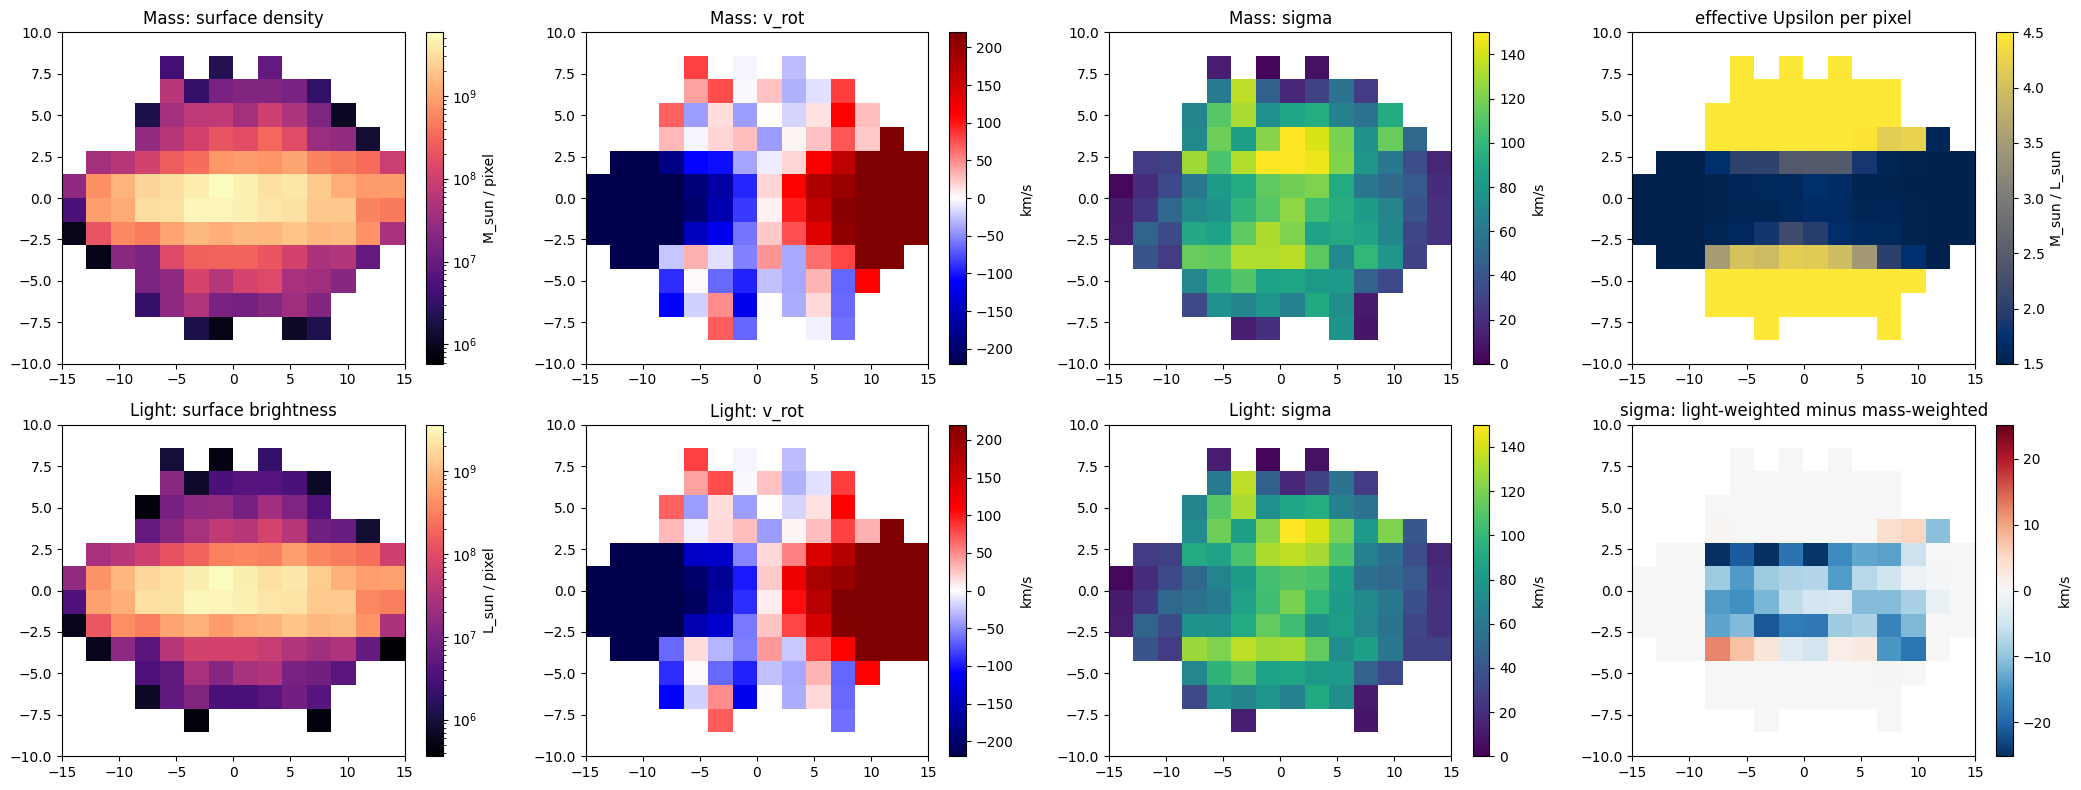

effective Upsilon over the footprint: min 1.50  median 2.13  max 4.50   (global 1.66)
sigma shift (light - mass): median -0.00 km/s   max|.| 36.96 km/s
v_rot shift (light - mass): max|.| 38.39 km/s


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(21, 8))
extent = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]

ims_m = plot_maps_row(axes[0, :3], obs_mass, mask_mass, 'Mass',
                      float(np.nanmax(np.array(obs_mass['mass']))), first_name='surface density')
ims_l = plot_maps_row(axes[1, :3], obs_light, mask_light, 'Light',
                      float(np.nanmax(np.array(obs_light['mass']))), first_name='surface brightness')
for ims, row, lab0 in [(ims_m, 0, 'M_sun / pixel'), (ims_l, 1, 'L_sun / pixel')]:
    for im, ax, lab in zip(ims, axes[row, :3], [lab0, 'km/s', 'km/s']):
        fig.colorbar(im, ax=ax, label=lab)

both = mask_mass & mask_light

# Effective M/L per pixel: the ratio of the two first maps. Where it departs from the
# global value, the light map is telling a different story from the mass map.
ml_eff = np.where(both, np.array(obs_mass['mass']) / np.maximum(np.array(obs_light['mass']), 1e-30), np.nan)
im = axes[0, 3].imshow(ml_eff, origin='lower', extent=extent, cmap='cividis', aspect='auto',
                       vmin=ML_DISK, vmax=ML_BULGE)
axes[0, 3].set_title('effective Upsilon per pixel')
fig.colorbar(im, ax=axes[0, 3], label='M_sun / L_sun')

# What the light-weighting does to the dispersion map.
d_sigma = np.where(both, np.array(obs_light['sigma'] - obs_mass['sigma']), np.nan)
lim = float(np.nanpercentile(np.abs(d_sigma), 99)) or 1.0
im = axes[1, 3].imshow(d_sigma, origin='lower', extent=extent, cmap='RdBu_r', aspect='auto',
                       vmin=-lim, vmax=lim)
axes[1, 3].set_title('sigma: light-weighted minus mass-weighted')
fig.colorbar(im, ax=axes[1, 3], label='km/s')

plt.tight_layout(); plt.show()

print(f"effective Upsilon over the footprint: min {np.nanmin(ml_eff):.2f}"
      f"  median {np.nanmedian(ml_eff):.2f}  max {np.nanmax(ml_eff):.2f}"
      f"   (global {ML_GLOBAL:.2f})")
print(f"sigma shift (light - mass): median {np.nanmedian(d_sigma):+.2f} km/s"
      f"   max|.| {np.nanmax(np.abs(d_sigma)):.2f} km/s")
print(f"v_rot shift (light - mass): max|.| "
      f"{np.nanmax(np.abs(np.where(both, np.array(obs_light['v_rot'] - obs_mass['v_rot']), np.nan))):.2f} km/s")

The effective-$\Upsilon$ panel is the whole experiment in one image. If the galaxy were a
single population it would be flat, and the luminosity map would be the mass map times a
constant. It is not flat: it runs from roughly $\Upsilon_{\rm disk}$ in the outer disk to
$\Upsilon_{\rm bulge}$ in the centre, because the two components dominate in different
places. That gradient is the *only* new structure a luminosity map contains, and it is
also the only thing that can be got wrong.

The bottom-right panel is the second effect: down-weighting the hot, pressure-supported
bulge lowers the light-weighted dispersion in the centre.

## 4. Control: a Constant $\Upsilon$ Changes Nothing

Before running any fit, it is worth being precise about what *cannot* help. If
$\Upsilon$ is the same for both components, then $L = M/\Upsilon$ everywhere, and:

- the first map enters the loss as a **log-space residual**,
  $\log_{10}(L_{\rm mod}+f) - \log_{10}(L_{\rm obs}+f)$, so with the floor $f$ scaled by
  the same $1/\Upsilon$ the constant cancels exactly;
- `v_rot` and `sigma` are **ratios** of weighted sums, so a common factor cancels there too.

So "fit the luminosity instead of the mass" is, by itself, not a change of information at
all — it is the same objective. Only a *component-dependent* $\Upsilon$ does anything.

The check below is run at a **perturbed** parameter point, not at the truth. At the truth
every correctly-specified variant has a data term of exactly zero (same seed, same
particles, the model reproduces its own mock), so an agreement there would be vacuous.
Away from the truth the three data terms are genuinely different numbers, and the
constant-$\Upsilon$ one still has to match the mass fit digit for digit.

In [7]:
LOSS_CHECK = dict(poisson_kwargs=POISSON_KWARGS,
                  loss_weights=(1.0, 1.0, 1.0, W_POISSON), **GRID_KW)

obs_const = make_observation(mapper, pot_params_true, disk_df_params_true,
                            bulge_df_params_true, ml_ratios=ML_ASSUMED, **GRID_KW)
FLOOR_CONST = FLOOR_FRAC * float(jnp.max(obs_const['mass']))

VARIANTS = [
    ('mass map',                 obs_mass,  None,        FLOOR_MASS),
    ('light, constant Upsilon',  obs_const, ML_ASSUMED,  FLOOR_CONST),
    ('light, component Upsilon', obs_light, ML_TRUE,     FLOOR_LIGHT),
]


def data_terms(obs, mlr, floor, p_log):
    """The three data-fit terms only -- the Poisson penalty is identical across all
    variants by construction (it uses the mass weights), so including it would mask
    exactly the differences being looked for."""
    lf = make_loss_fn(mapper, obs, mass_floor=floor, ml_ratios=mlr, **LOSS_CHECK)
    _, aux = lf(p_log, OBS_BANDWIDTH)
    return tuple(float(aux[k]) for k in ('mass_loss', 'vrot_loss', 'sigma_loss'))


p_true_log = params_to_log(pot_params_true, disk_df_params_true, bulge_df_params_true)
# A moderate displacement: enough that the data terms are well away from zero, close
# enough that the model still overlaps the data.
p_off_log = params_to_log({k: v * 1.3 for k, v in pot_params_true.items()},
                          disk_df_params_true, bulge_df_params_true)

print(f"data-fit terms at a PERTURBED point (potential x1.3)")
print(f"{'variant':26s} {'first map':>12s} {'v_rot':>12s} {'sigma':>12s}")
rows = {}
for name, obs, mlr, floor in VARIANTS:
    rows[name] = data_terms(obs, mlr, floor, p_off_log)
    print(f"{name:26s} " + ' '.join(f"{v:12.8f}" for v in rows[name]))

scale = max(rows['mass map'])
same = max(abs(a - b) for a, b in zip(rows['mass map'], rows['light, constant Upsilon']))
diff = max(abs(a - b) for a, b in zip(rows['mass map'], rows['light, component Upsilon']))
# Everything runs in float32, so the cancellation is exact only up to accumulated
# round-off: the bar is round-off, not bit-equality.
print(f"\nmass vs constant-Upsilon : max difference {same:.3e}  ({same/scale:.1e} relative)"
      f"  ->  the same objective to float32 round-off: {same < 1e-4 * scale}")
print(f"mass vs component-Upsilon: max difference {diff:.3e}  ({diff/scale:.1e} relative)"
      f"  ->  a genuinely different objective: {diff > 1e-2 * scale}")

# The systematic fit C has to live with: the model assumes ONE Upsilon while the data
# was made with two. Unlike a correctly-specified fit, this does NOT vanish at the truth.
print(f"\n{'':26s} {'first map':>12s} {'v_rot':>12s} {'sigma':>12s}")
ok = data_terms(obs_light, ML_TRUE, FLOOR_LIGHT, p_true_log)
mis = data_terms(obs_light, ML_ASSUMED, FLOOR_LIGHT, p_true_log)
print(f"{'at truth, Upsilon correct':26s} " + ' '.join(f"{v:12.8f}" for v in ok))
print(f"{'at truth, Upsilon global':26s} " + ' '.join(f"{v:12.8f}" for v in mis))
print(f"\nWith the correct Upsilon the truth is an exact zero of the data term. With one"
      f"\nglobal Upsilon it is not: {sum(mis):.5f} of irreducible residual that no choice of"
      f"\nparameters can remove. The fit will trade real parameters against it.")


data-fit terms at a PERTURBED point (potential x1.3)
variant                       first map        v_rot        sigma


mass map                     0.50424850   0.08457498   0.14892638


light, constant Upsilon      0.50424850   0.08457498   0.14892524


light, component Upsilon     0.46895334   0.08033000   0.13845846

mass vs constant-Upsilon : max difference 1.132e-06  (2.2e-06 relative)  ->  the same objective to float32 round-off: True
mass vs component-Upsilon: max difference 3.530e-02  (7.0e-02 relative)  ->  a genuinely different objective: True

                              first map        v_rot        sigma


at truth, Upsilon correct    0.00000000   0.00000000   0.00000000
at truth, Upsilon global     0.07413545   0.00273903   0.00751497

With the correct Upsilon the truth is an exact zero of the data term. With one
global Upsilon it is not: 0.08439 of irreducible residual that no choice of
parameters can remove. The fit will trade real parameters against it.


## 5. The Far-Off Start

The same hard regime as the previous notebooks: potential parameters ~5.3x too large, the
disk DF 2.5x too large, the bulge DF 10x too small. All three fits start here.

In [8]:
pot_params_init = {k: v * 5.3 for k, v in pot_params_true.items()}
disk_df_params_init = {k: v * 2.5 for k, v in disk_df_params_true.items()}
bulge_df_params_init = {k: v * 0.1 for k, v in bulge_df_params_true.items()}

FIT_KW = dict(**GRID_KW, poisson_kwargs=POISSON_KWARGS,
              loss_weights=(1.0, 1.0, 1.0, W_POISSON),
              learning_rate=0.05, frozen_params=FROZEN)
LOSS_KW = {k: v for k, v in FIT_KW.items() if k not in ('learning_rate', 'frozen_params')}

N_ADAM = 700
N_LBFGS = 150
LBFGS_MEMORY = 10

## 6. The Optimizer

`lbfgs_refine` is carried over unchanged from `optimization_pipeline_adam_lbfgs.ipynb` —
see Section 7 there for why it is built the way it is (fixed bandwidth, frozen parameters
deleted rather than zeroed, bounds by projection).

In [9]:
def _split_frozen(tree, frozen_params):
    """Splits a params_log pytree into its free and frozen leaves."""
    free = {g: {k: v for k, v in grp.items() if k not in frozen_params}
            for g, grp in tree.items()}
    fixed = {g: {k: v for k, v in grp.items() if k in frozen_params}
             for g, grp in tree.items()}
    return free, fixed


def lbfgs_refine(loss_fn, init_params_log, soft_bin_h=None, param_bounds=None,
                 frozen_params=(), n_steps=100, memory_size=10,
                 max_linesearch_steps=30, grad_tol=1e-7, stall_tol=1e-9,
                 max_stalls=3, verbose_every=10):
    """L-BFGS refinement of a `params_log` pytree at a FIXED bandwidth.

    Second-order polish for the point Adam leaves behind. Adam takes a fixed-size step
    along a rescaled gradient and cannot exploit curvature, so on the long narrow valleys
    this loss has it creeps; L-BFGS builds a low-rank inverse-Hessian estimate from the
    last `memory_size` (step, gradient-change) pairs and picks both the direction and --
    via a Wolfe zoom line search -- the distance. Frozen parameters are removed from the
    optimized vector rather than gradient-zeroed, and the box constraints are enforced by
    projection after each accepted step.
    """
    free, fixed = _split_frozen(init_params_log, frozen_params)
    log_lo, log_hi = log_bounds_tree(init_params_log, param_bounds)
    lo_free, _ = _split_frozen(log_lo, frozen_params)
    hi_free, _ = _split_frozen(log_hi, frozen_params)

    h = None if soft_bin_h is None else jnp.asarray(soft_bin_h, jnp.float32)

    def merge(free_tree):
        return {g: {**fixed[g], **free_tree[g]} for g in init_params_log}

    def loss_aux(free_tree):
        return loss_fn(merge(free_tree), h)

    def value_fn(free_tree):          # scalar-only: this is what the line search calls
        return loss_aux(free_tree)[0]

    opt = optax.lbfgs(
        memory_size=memory_size,
        linesearch=optax.scale_by_zoom_linesearch(
            max_linesearch_steps=max_linesearch_steps),
    )

    @jax.jit
    def step(free_tree, state):
        (value, aux), grad = jax.value_and_grad(loss_aux, has_aux=True)(free_tree)
        grad = jax.tree_util.tree_map(lambda g: jnp.where(jnp.isfinite(g), g, 0.0), grad)
        updates, state = opt.update(grad, state, free_tree,
                                    value=value, grad=grad, value_fn=value_fn)
        stepped = optax.apply_updates(free_tree, updates)
        clipped = jax.tree_util.tree_map(jnp.clip, stepped, lo_free, hi_free)
        projected = ravel_pytree(jax.tree_util.tree_map(
            lambda a, b: jnp.abs(a - b), stepped, clipped))[0].max()
        gnorm = jnp.abs(ravel_pytree(grad)[0]).max()
        return clipped, state, value, aux, gnorm, projected

    @jax.jit
    def evaluate(free_tree):
        return loss_aux(free_tree)

    history = {k: [] for k in ('loss', 'mass_loss', 'vrot_loss', 'sigma_loss',
                               'poisson_penalty', 'reg', 'pot_params',
                               'disk_df_params', 'bulge_df_params')}

    def record(value, aux, free_tree):
        pot, disk, bulge = log_to_params(merge(free_tree))
        history['loss'].append(float(value))
        for k in ('mass_loss', 'vrot_loss', 'sigma_loss', 'poisson_penalty', 'reg'):
            history[k].append(float(aux[k]))
        history['pot_params'].append({k: float(v) for k, v in pot.items()})
        history['disk_df_params'].append({k: float(v) for k, v in disk.items()})
        history['bulge_df_params'].append({k: float(v) for k, v in bulge.items()})

    state = opt.init(free)
    best_free, best_loss = free, np.inf
    stalls, n_projected, stop_reason = 0, 0, f'reached n_steps={n_steps}'
    prev = np.inf

    for i in range(n_steps):
        free, state, value, aux, gnorm, projected = step(free, state)
        value, gnorm = float(value), float(gnorm)
        record(value, aux, free)      # loss BEFORE this step, params AFTER it
        if projected > 0:
            n_projected += 1
        if not np.isfinite(value):
            stop_reason = f'non-finite loss at iteration {i}'
            break
        if value < best_loss:
            best_loss, best_free = value, free
        if verbose_every and (i % verbose_every == 0 or i == n_steps - 1):
            print(f"  lbfgs {i:4d}   loss {value:.6f}   |grad|_inf {gnorm:.3e}")
        if gnorm < grad_tol:
            stop_reason = f'gradient below {grad_tol:g} at iteration {i}'
            break
        if abs(prev - value) < stall_tol * max(1.0, abs(prev)):
            stalls += 1
            if stalls >= max_stalls:
                stop_reason = f'no progress for {max_stalls} iterations (line search stalled)'
                break
        else:
            stalls = 0
        prev = value

    final_value, final_aux = evaluate(best_free)
    record(final_value, final_aux, best_free)

    pot, disk, bulge = log_to_params(merge(best_free))
    if verbose_every:
        print(f"  stopped: {stop_reason}")
        if n_projected:
            print(f"  WARNING: bounds projection active on {n_projected} iterations "
                  f"-- the refinement is projected L-BFGS, not plain L-BFGS")
    return {
        'pot_params': pot, 'disk_df_params': disk, 'bulge_df_params': bulge,
        'params_log': merge(best_free), 'history': history,
        'n_iter': len(history['loss']) - 1, 'stop_reason': stop_reason,
        'n_projected': n_projected,
    }

## 7. The Three Fits

Same start, same optimizer, same number of steps. The only difference between the chains
is `obs` / `ml_ratios` / `mass_floor`.

**A caution about comparing losses across the three.** Each fit minimizes a *different*
objective, computed on a different map with a different footprint, so their loss values
are not comparable numbers. The comparison that means anything is **parameter recovery
against the known ground truth**, which is the same in all three cases. Section 10 uses
that, not the loss.

In [10]:
CONFIGS = [
    ('A  mass',              obs_mass,  None,        FLOOR_MASS),
    ('B  light, Y known',    obs_light, ML_TRUE,     FLOOR_LIGHT),
    ('C  light, Y global',   obs_light, ML_ASSUMED,  FLOOR_LIGHT),
]

results = {}
for tag, obs, mlr, floor in CONFIGS:
    print("=" * 78)
    print(f"FIT {tag}    ml_ratios={mlr}")
    print("=" * 78)
    res_adam = fit(mapper, obs, pot_params_init, disk_df_params_init,
                   bulge_df_params_init, n_steps=N_ADAM,
                   anneal_bandwidth=(8.0, OBS_BANDWIDTH),
                   obs_bandwidth=OBS_BANDWIDTH,
                   ml_ratios=mlr, mass_floor=floor, **FIT_KW)

    # Same objective the Adam hold phase was descending, rebuilt for the polish.
    loss_fn = make_loss_fn(mapper, obs, obs_bandwidth=OBS_BANDWIDTH,
                           ml_ratios=mlr, mass_floor=floor, **LOSS_KW)
    p_log = params_to_log(res_adam['pot_params'], res_adam['disk_df_params'],
                          res_adam['bulge_df_params'])
    res_lb = lbfgs_refine(loss_fn, p_log, soft_bin_h=OBS_BANDWIDTH,
                          frozen_params=FROZEN, n_steps=N_LBFGS,
                          memory_size=LBFGS_MEMORY, verbose_every=25)

    results[tag] = dict(adam=res_adam, final=res_lb, loss_fn=loss_fn,
                        obs=obs, ml_ratios=mlr, floor=floor)
    print()

errs = {}
for tag, _, _, _ in CONFIGS:
    errs[tag] = report(f"\n{tag}   (Adam + L-BFGS)", results[tag]['final'], truth)

FIT A  mass    ml_ratios=None


    [fit] note: non-finite gradients on 1/700 steps (0%); 21 parameter-gradients were zeroed. Affected parameters are held at whatever value they had, so a 'converged' result here may simply be the initial guess.


  lbfgs    0   loss 0.008100   |grad|_inf 7.448e-05


  stopped: no progress for 3 iterations (line search stalled)



FIT B  light, Y known    ml_ratios=(1.5, 4.5)


...

  lbfgs    0   loss 0.011768   |grad|_inf 6.020e-04


  lbfgs   25   loss 0.011664   |grad|_inf 1.261e-03


  lbfgs   50   loss 0.011646   |grad|_inf 5.598e-04


  lbfgs   75   loss 0.011642   |grad|_inf 5.952e-04


  stopped: no progress for 3 iterations (line search stalled)


A  mass   (Adam + L-BFGS)
    loss    0.008 ->   0.0081
    poisson residual at end: 0.0425
    POTENTIAL (7):  median    0.9%   within 20%: 7/7
    all constrained (17): median   35.7%   within 20%: 8/17

B  light, Y known   (Adam + L-BFGS)
    loss    0.008 ->   0.0084
    poisson residual at end: 0.0426
    POTENTIAL (7):  median    1.1%   within 20%: 7/7
    all constrained (17): median   41.2%   within 20%: 7/17

C  light, Y global   (Adam + L-BFGS)
    loss    0.012 ->   0.0116
    poisson residual at end: 0.0565
    POTENTIAL (7):  median    3.7%   within 20%: 7/7
    all constrained (17): median   22.4%   within 20%: 8/17


## 8. Convergence

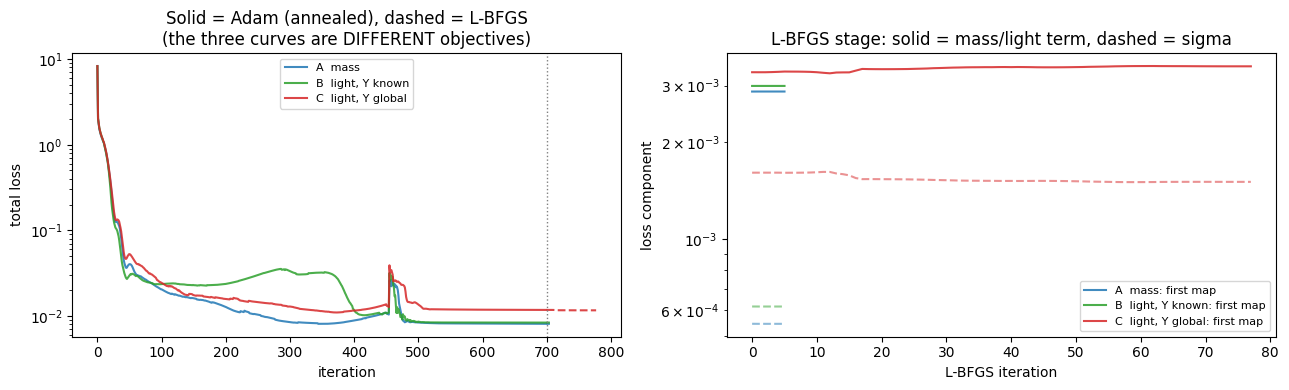

A  mass                L-BFGS 0.008100 -> 0.008100  (5 iters, no progress for 3 iterations (line search stalled))
B  light, Y known      L-BFGS 0.008372 -> 0.008372  (5 iters, no progress for 3 iterations (line search stalled))
C  light, Y global     L-BFGS 0.011768 -> 0.011642  (77 iters, no progress for 3 iterations (line search stalled))


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {'A  mass': 'tab:blue', 'B  light, Y known': 'tab:green', 'C  light, Y global': 'tab:red'}

for tag in results:
    h_a = results[tag]['adam']['history']['loss']
    h_l = results[tag]['final']['history']['loss']
    x_l = np.arange(len(h_a), len(h_a) + len(h_l))
    axes[0].plot(h_a, color=colors[tag], label=tag, alpha=0.85)
    axes[0].plot(x_l, h_l, color=colors[tag], ls='--', alpha=0.85)
axes[0].axvline(N_ADAM, color='gray', ls=':', lw=1)
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title('Solid = Adam (annealed), dashed = L-BFGS\n(the three curves are DIFFERENT objectives)')
axes[0].legend(fontsize=8)

for tag in results:
    h = results[tag]['final']['history']
    axes[1].plot(h['mass_loss'], color=colors[tag], label=f'{tag}: first map', alpha=0.85)
    axes[1].plot(h['sigma_loss'], color=colors[tag], ls='--', alpha=0.5)
axes[1].set_yscale('log'); axes[1].set_xlabel('L-BFGS iteration')
axes[1].set_ylabel('loss component')
axes[1].set_title('L-BFGS stage: solid = mass/light term, dashed = sigma')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for tag in results:
    r = results[tag]['final']
    h = r['history']['loss']
    print(f"{tag:22s} L-BFGS {h[0]:.6f} -> {h[-1]:.6f}  "
          f"({r['n_iter']} iters, {r['stop_reason']})")

## 9. Map Comparison

Each fit is rendered through **its own** forward model — fit B and C produce light maps,
fit A a mass map — and differenced against the data it was fitted to. The residual
columns are therefore each internally consistent, even though the first row's units
differ between A and B/C.

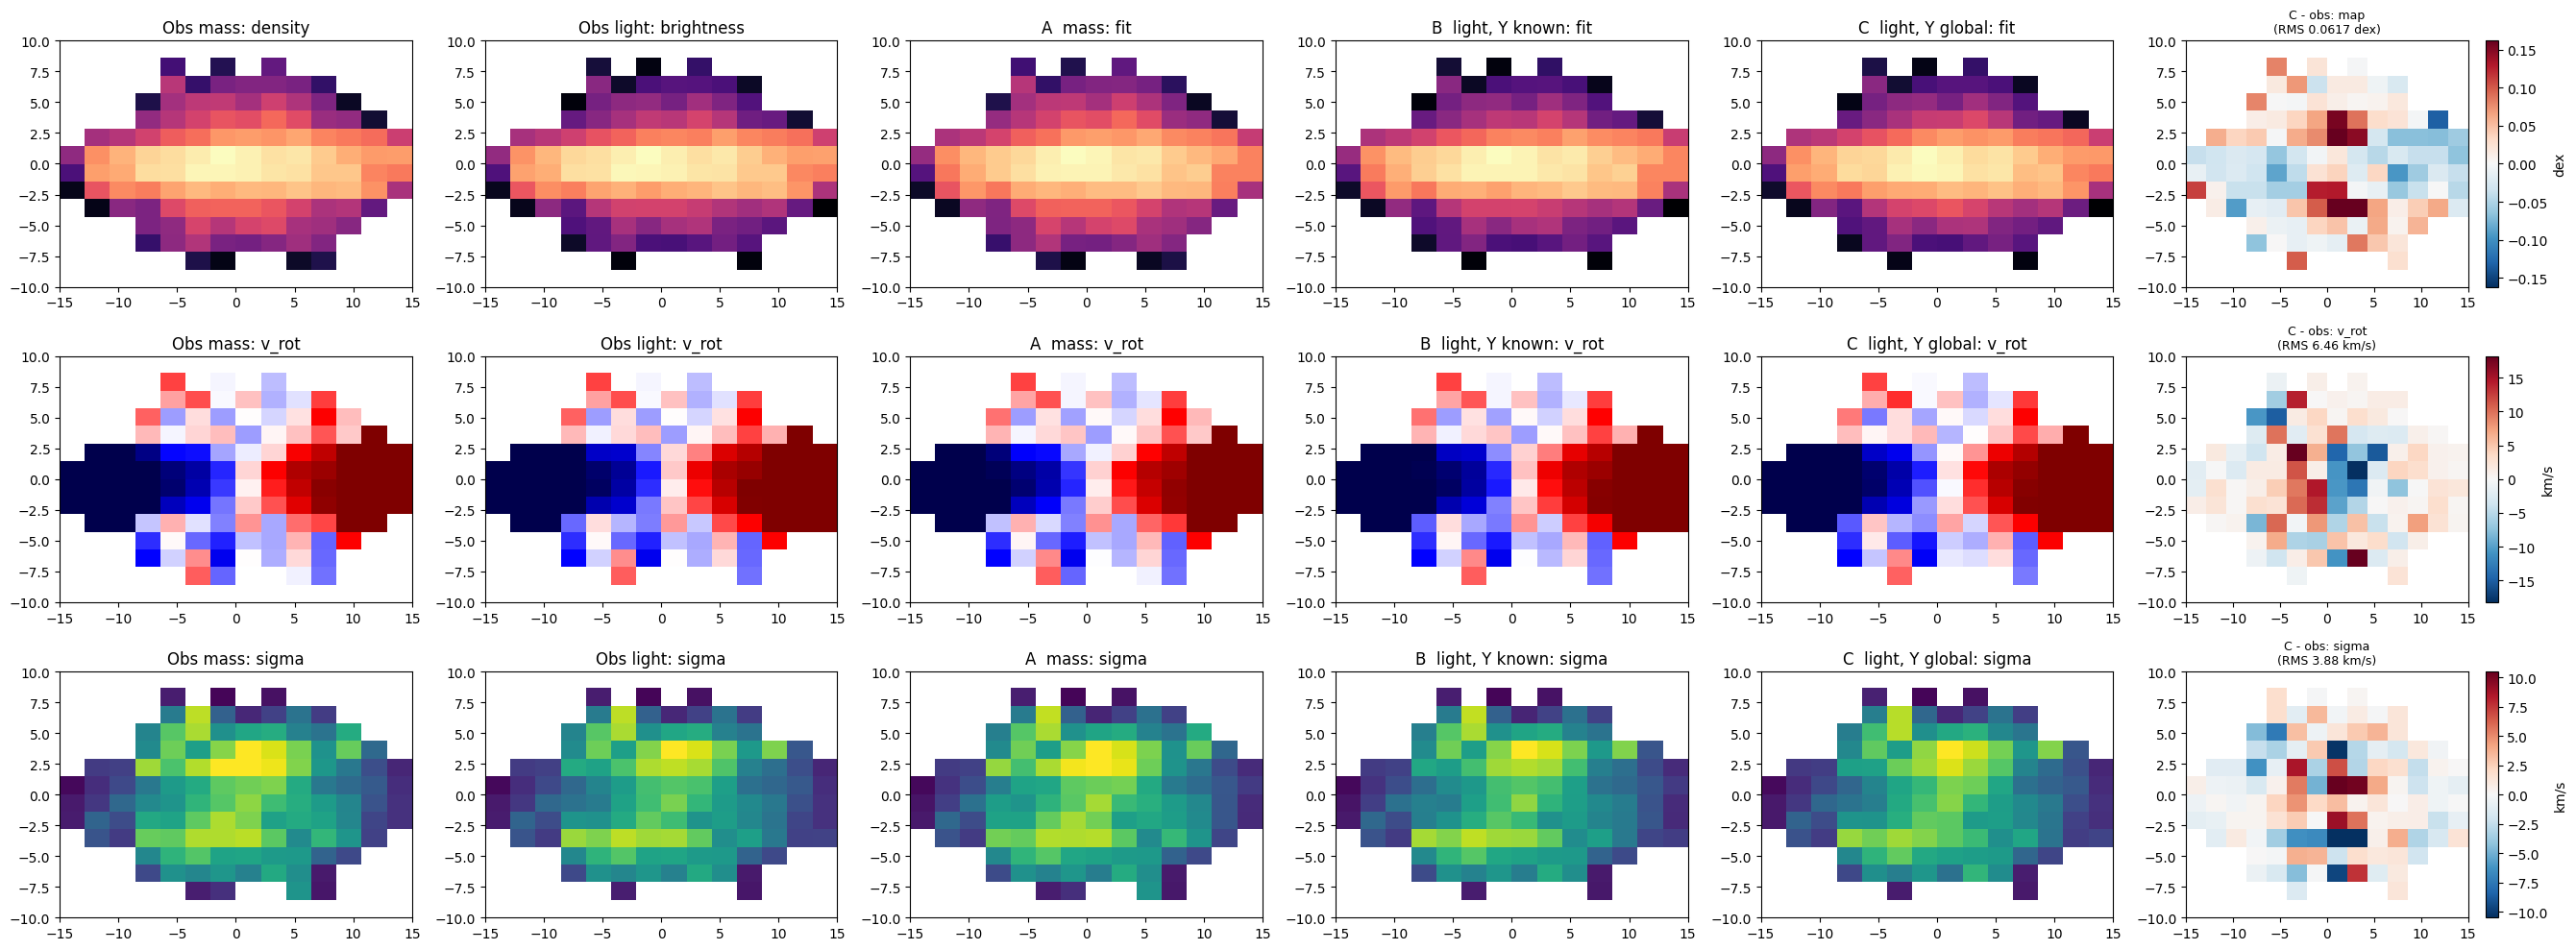

A  mass minus its own observation, over its footprint:
  map  : RMS   0.0550 dex   median  +0.0043  max|.|   0.3341
  v_rot: RMS   4.1653 km/s  median  -0.1780  max|.|  26.3162
  sigma: RMS   2.3343 km/s  median  -0.0593  max|.|  12.5285
B  light, Y known minus its own observation, over its footprint:
  map  : RMS   0.0562 dex   median  +0.0064  max|.|   0.3343
  v_rot: RMS   4.4701 km/s  median  -0.2021  max|.|  29.3230
  sigma: RMS   2.4836 km/s  median  -0.0298  max|.|  12.4379
C  light, Y global minus its own observation, over its footprint:
  map  : RMS   0.0617 dex   median  -0.0005  max|.|   0.2653
  v_rot: RMS   6.4606 km/s  median  +0.6735  max|.|  21.0168
  sigma: RMS   3.8807 km/s  median  +0.0533  max|.|  17.4083


In [12]:
def residual_maps(model, obs, mask):
    """Model minus observation, in the units each term is compared in by the loss:
    the first map as a log10 ratio (dex), the kinematics as differences (km/s)."""
    mm, om = np.array(model['mass']), np.array(obs['mass'])
    floor = 1e-4 * np.nanmax(om)
    d_first = np.log10(np.maximum(mm, floor)) - np.log10(np.maximum(om, floor))
    d_vrot = np.array(model['v_rot']) - np.array(obs['v_rot'])
    d_sigma = np.array(model['sigma']) - np.array(obs['sigma'])
    return [np.where(mask, d, np.nan) for d in (d_first, d_vrot, d_sigma)]


def plot_residual_row(axes, model, obs, mask, title_prefix):
    extent = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
    resids = residual_maps(model, obs, mask)
    labels = [('map', 'dex', 0.05), ('v_rot', 'km/s', 5.0), ('sigma', 'km/s', 5.0)]
    ims = []
    for ax, d, (name, unit, floor) in zip(axes, resids, labels):
        finite = d[np.isfinite(d)]
        lim = max(float(np.percentile(np.abs(finite), 98)) if finite.size else floor, floor)
        rms = float(np.sqrt(np.nanmean(d ** 2)))
        im = ax.imshow(d, origin='lower', extent=extent, cmap='RdBu_r',
                       vmin=-lim, vmax=lim, aspect='auto')
        ax.set_title(f'{title_prefix}: {name}\n(RMS {rms:.3g} {unit})', fontsize=9)
        ims.append(im)
    return ims


fit_maps = {}
for tag in results:
    r = results[tag]
    fit_maps[tag] = generate_edge_on_maps(
        mapper, r['final']['pot_params'], r['final']['disk_df_params'],
        r['final']['bulge_df_params'], ml_ratios=r['ml_ratios'], **GRID_KW)

fig, axes = plt.subplots(3, 6, figsize=(27, 10))
plot_maps_row(axes[:, 0], obs_mass, mask_mass, 'Obs mass',
              float(np.nanmax(np.array(obs_mass['mass']))), first_name='density')
plot_maps_row(axes[:, 1], obs_light, mask_light, 'Obs light',
              float(np.nanmax(np.array(obs_light['mass']))), first_name='brightness')
for j, tag in enumerate(results):
    r = results[tag]
    msk = mask_mass if r['ml_ratios'] is None else mask_light
    plot_maps_row(axes[:, 2 + j], fit_maps[tag], msk, tag,
                  float(np.nanmax(np.array(r['obs']['mass']))), first_name='fit')
res_ims = plot_residual_row(axes[:, 5], fit_maps['C  light, Y global'], obs_light,
                            mask_light, 'C - obs')
for im, ax, lab in zip(res_ims, axes[:, 5], ['dex', 'km/s', 'km/s']):
    fig.colorbar(im, ax=ax, label=lab)
plt.tight_layout(); plt.show()

for tag in results:
    r = results[tag]
    msk = mask_mass if r['ml_ratios'] is None else mask_light
    d_first, d_vrot, d_sigma = residual_maps(fit_maps[tag], r['obs'], msk)
    print(f"{tag} minus its own observation, over its footprint:")
    for nm, d, unit in [('map  ', d_first, 'dex'), ('v_rot', d_vrot, 'km/s'),
                        ('sigma', d_sigma, 'km/s')]:
        print(f"  {nm}: RMS {np.sqrt(np.nanmean(d**2)):8.4f} {unit:4s}  "
              f"median {np.nanmedian(d):+8.4f}  max|.| {np.nanmax(np.abs(d)):8.4f}")

## 10. Parameter Recovery — the Answer

This is the comparison that decides the question. All three fits are scored against the
*same* ground truth, so unlike the losses these numbers are directly comparable.

parameter                true  init err        A        B        C
-- potential
M_bulge             1.388e+10      430%       2%       2%      18%
M_disk              8.055e+10      430%       1%       1%       0%
M_halo                  1e+12      430%       3%       4%       4%
a_bulge               0.05805      430%       0%       5%      10%
a_disk                  8.072      430%       0%       0%       1%
a_halo                     20      430%       0%       1%       5%
b_disk                  1.456      430%       1%       1%       2%
-- disk DF
L0                         10      150%     150%     150%     150%  (frozen)
R0                          8      150%      36%      22%       7%
Rd                          3      150%      68%      68%      40%
Rinit_for_Rc                8      150%     150%     150%     150%  (frozen)
RsigR                       6      150%     387%     390%     325%
RsigZ                       6      150%     400%     400%      39%
Sigma0            

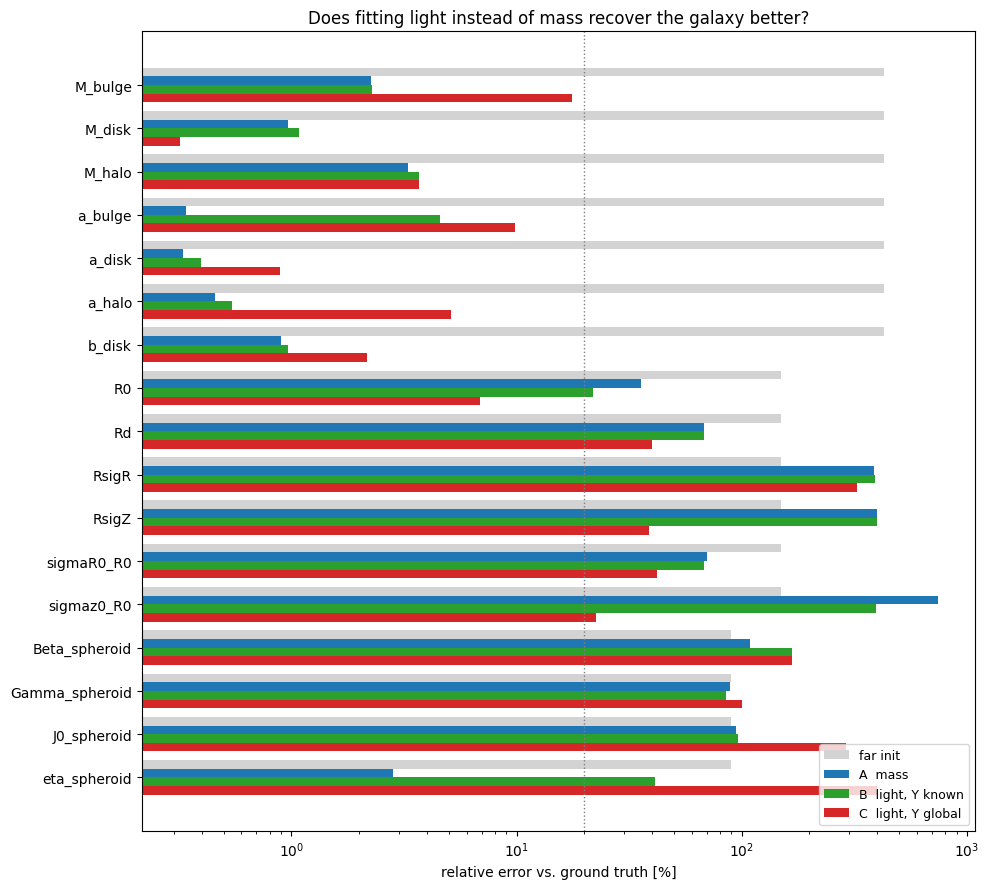


                           potential (7)   all constrained (17)
median error  A  mass                        0.9%                35.7%
median error  B  light, Y known              1.1%                41.2%
median error  C  light, Y global             3.7%                22.4%

verdict, on the potential parameters (the part these maps actually constrain):
  B  light, Y known         1.1%  vs  mass   0.9%   -> WORSE by 0.2 percentage points
  C  light, Y global        3.7%  vs  mass   0.9%   -> WORSE by 2.8 percentage points


In [13]:
all_init = {**pot_params_init, **disk_df_params_init, **bulge_df_params_init}
groups = [('potential', list(pot_params_true)),
          ('disk DF', list(disk_df_params_true)),
          ('bulge DF', list(bulge_df_params_true))]
tags = list(results)

hdr = ''.join(f"{t.split()[0]:>9s}" for t in tags)
print(f"{'parameter':16s} {'true':>12s} {'init err':>9s}{hdr}")
for gname, keys in groups:
    print(f"-- {gname}")
    for k in keys:
        ie = abs(all_init[k] - truth[k]) / abs(truth[k]) * 100
        row = ''.join(f"{errs[t][k]:8.0f}%" for t in tags)
        flag = '  (frozen)' if k in FROZEN else ''
        print(f"{k:16s} {truth[k]:12.4g} {ie:8.0f}%{row}{flag}")

keys = [k for k in truth if k not in FROZEN]
pot_keys = list(pot_params_true)

yv = np.arange(len(keys))
hgt = 0.2
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(yv - 1.5 * hgt, [abs(all_init[k] - truth[k]) / abs(truth[k]) * 100 for k in keys],
        height=hgt, color='lightgray', label='far init')
for j, t in enumerate(tags):
    ax.barh(yv + (j - 0.5) * hgt, [errs[t][k] for k in keys], height=hgt,
            color=colors[t], label=t)
ax.set_yticks(yv); ax.set_yticklabels(keys); ax.invert_yaxis()
ax.set_xscale('log'); ax.axvline(20, color='gray', ls=':', lw=1)
ax.set_xlabel('relative error vs. ground truth [%]')
ax.set_title('Does fitting light instead of mass recover the galaxy better?')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

print(f"\n{'':24s} {'potential (7)':>15s} {'all constrained (17)':>22s}")
summary = {}
for t in tags:
    mp = float(np.median([errs[t][k] for k in pot_keys]))
    ma = float(np.median([errs[t][k] for k in keys]))
    summary[t] = (mp, ma)
    print(f"median error  {t:22s} {mp:11.1f}% {ma:19.1f}%")

base = summary['A  mass'][0]
print("\nverdict, on the potential parameters (the part these maps actually constrain):")
for t in tags[1:]:
    d = summary[t][0] - base
    word = 'BETTER' if d < 0 else 'WORSE'
    print(f"  {t:22s} {summary[t][0]:6.1f}%  vs  mass {base:5.1f}%   "
          f"-> {word} by {abs(d):.1f} percentage points")

## 11. Summary

**No — fitting the luminosity map does not give better results, and in the realistic
case it gives distinctly worse ones.**

| fit | potential parameters, median relative error |
|---|---|
| **A** mass map | **0.9 %** |
| **B** light, $\Upsilon$ known per component | **1.1 %** |
| **C** light, one global $\Upsilon$ | **3.7 %** |

Three separate statements, in increasing order of how much they matter:

**1. A constant $\Upsilon$ is not a change at all.** Section 4 measures it: the mass map
and a constant-$\Upsilon$ light map give the same data-fit terms to float32 round-off
($2\times10^{-6}$ relative). The first map enters the loss as a log-space residual and the
kinematic maps are ratios of weighted sums, so a common factor cancels on both sides.
"Fit the light instead of the mass" is, by itself, a relabelling.

**2. With a correctly known component $\Upsilon$, light is as good as mass — not better.**
1.1 % against 0.9 %, with all 7 potential parameters inside 20 % either way. The
difference is optimizer noise, not information. This is the expected answer: converting to
light re-weights *which* combination of disk and bulge each pixel reports, but one scalar
map plus two kinematic maps still pins down the same potential. There is no extra
constraint hiding in the photometry.

**3. Assuming a single global $\Upsilon$ costs about a factor of four**, and the damage
lands precisely where the $\Upsilon$ gradient is:

| parameter | A mass | C global $\Upsilon$ |
|---|---|---|
| `M_bulge` | 2 % | **18 %** |
| `a_bulge` | 0 % | **10 %** |
| `a_halo`  | 0 % | **5 %** |
| `M_disk`  | 1 % | 0 % |

The disk, which dominates the light and therefore sets $\Upsilon_{\rm global}$, is
recovered fine. The bulge — the component whose $\Upsilon$ was got wrong by a factor of
2.7 — is not. Section 4 shows the mechanism directly: with one $\Upsilon$ the true
parameters are no longer a zero of the data term (0.084 of irreducible residual), so the
optimizer spends real physical parameters buying that residual down. Fit C's other
symptoms agree: its L-BFGS stage sat against the parameter bounds on 73 of 77 iterations,
and its map residuals are worse in *every* channel (`v_rot` RMS 6.5 vs 4.2 km/s, `sigma`
3.9 vs 2.3 km/s) despite having more freedom to cheat.

### One number not to over-read

In the "all constrained (17)" column fit C looks *better* (22.4 % vs 35.7 %). That is not
a win. That median is dominated by the DF **shape** parameters, which a single edge-on
projection does not constrain — the same flat directions
`optimization_pipeline_adam_lbfgs.ipynb` identifies, and which the default sampler makes
flatter still (below). A better-converged value along a flat direction is still an
arbitrary point on it. The potential parameters are the part these maps actually
determine, and that is the column the verdict uses.

### The sampler switch, and why the default is still `'soft'`

`sampler` is now threaded through `make_observation` and `make_self_consistent_truth` as
well as `fit`/`make_loss_fn`, so setting `SAMPLER = 'importance'` in Section 1 switches
the mock, the self-consistency solve, the loss and every render together. Before relying
on that, it is worth knowing what it does.

**The objective is fine, and importance sampling does what it promises.** Scanning the
exact data-fit loss (no annealing, physics term off) around the self-consistent truth
gives a clean minimum at the truth under *both* samplers. What changes is where the
curvature sits — the loss at 1.3x the true value of one parameter at a time:

| scanned parameter | `soft` | `importance` |
|---|---|---|
| `M_disk` | 0.394 | 0.0078 |
| `sigmaR0_R0` | 0.0003 | 0.0516 |

Under `soft` the disk mass is sharply constrained while `sigmaR0_R0` is flat to three
decimals — the DF really is inert, exactly as its docstring warns. Under `importance` the
dispersion parameter acquires genuine curvature. That is the improvement one wants.

**What does not survive is the optimization.** The potential's curvature drops by ~50x at
the same time, and the Adam -> L-BFGS recipe inherited from
`optimization_pipeline_adam_lbfgs.ipynb` — whose annealing schedule, learning rate and
`W_POISSON` were all tuned against the soft objective — no longer converges. Measured on
fit A (the mass fit) alone:

| start | annealing | `w_poisson` | potential median error |
|---|---|---|---|
| 5.3x | on | 0.1 | 76 % |
| 5.3x | on | 0.01 | 73 % |
| 5.3x | on | 0.001 | 46 % |
| 5.3x | on | 0 | 98 % |
| 2.0x | on | 0.1 | 66 % |
| 2.0x | off | 0.1 | 37 % |
| 1.5x | on | 0.1 | 64 % |
| 1.5x | off | 0.1 | 52 % |

against **0.9 %** under `soft`. Even from a start only 1.5x off, with annealing disabled
and the physics term removed entirely, the fit ends at a data-fit loss of 0.34 where the
truth scores 0. So this is neither the Poisson weight nor the starting distance: the whole
schedule needs re-tuning for an objective two orders of magnitude flatter in the potential
directions, and that is a separate piece of work from the mass-to-light question.

The three-way comparison above is therefore run under `soft`, where all three chains
converge to sub-percent potential errors and the differences between them are attributable
to the photometry rather than to optimizer failure. The cost is that the DF-shape rows of
the recovery table are not measurements.

### What to do about $\Upsilon$ instead

Photometry is the observable you actually have, so the question is not whether to use
light but what to do about $\Upsilon$:

- **fit $\Upsilon$**, one per component, as free parameters alongside the dynamics. The
  light map then constrains $M/\Upsilon$ and the kinematics break the degeneracy. This
  needs `ml_ratios` promoted from a fixed argument to part of the optimized pytree —
  `params_to_log` / `log_to_params` / `DEFAULT_PARAM_BOUNDS` would all have to learn
  about it;
- **or measure $\Upsilon$ externally**, from colours or stellar-population fits, and pass
  it in as `ml_ratios`. That is fit B, and it recovers the mass-map answer.

What does not work is the middle course this notebook tests: taking a single number for a
galaxy that has two populations.